In [1]:
import yfinance as yf
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
import itertools
import seaborn as sns
import time
import re
import string
import chardet
import html

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_w = pd.read_excel('WMT_dati_storici.xlsx')
# Converti la colonna 'Date' in formato datetime
df_w['Date'] = pd.to_datetime(df_w['Date'])
print(df_w.head())

        Date      Open      High       Low     Close   Volume  Dividends  \
0 1972-08-25  0.011431  0.011651  0.011431  0.011607  7526400        0.0   
1 1972-08-28  0.011607  0.011695  0.011563  0.011563  2918400        0.0   
2 1972-08-29  0.011519  0.011519  0.011431  0.011431  5836800        0.0   
3 1972-08-30  0.011431  0.011431  0.011343  0.011431  1228800        0.0   
4 1972-08-31  0.011343  0.011343  0.011255  0.011255  2611200        0.0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


Date dei dividendi:
            Date  Dividends
365   1974-03-13   0.000033
472   1974-09-10   0.000033
590   1975-03-11   0.000020
661   1975-06-23   0.000020
712   1975-09-08   0.000020
...          ...        ...
12944 2024-03-14   0.208000
12983 2024-05-09   0.208000
13051 2024-08-16   0.208000
13134 2024-12-13   0.208000
13199 2025-03-21   0.235000

[203 rows x 2 columns]

Date degli stock split:
            Date  Stock Splits
704   1975-08-25             2
2044  1980-12-17             2
2438  1982-07-12             2
2691  1983-07-11             2
3258  1985-10-07             2
3703  1987-07-13             2
4459  1990-07-09             2
5127  1993-02-26             2
6678  1999-04-20             2
12931 2024-02-26             3


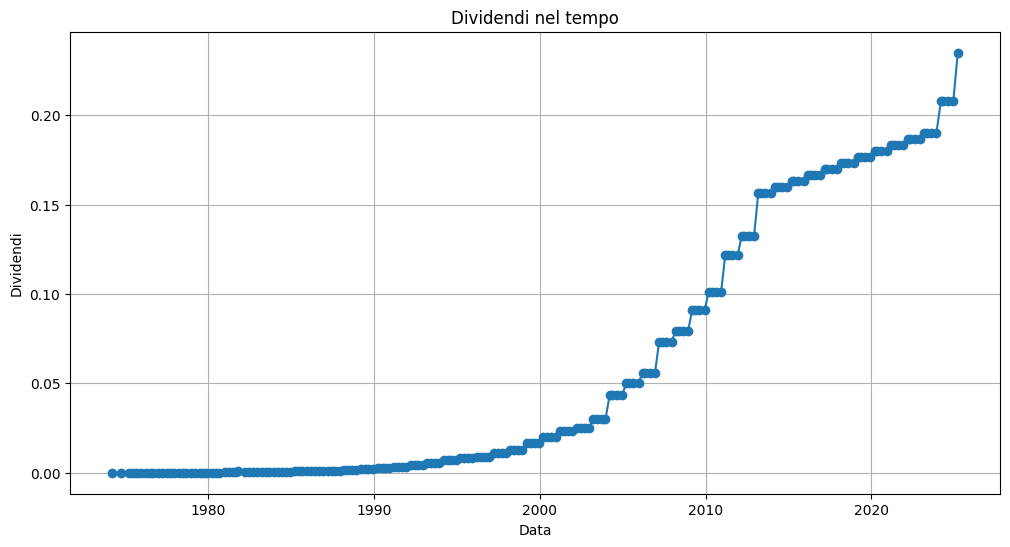

In [3]:
# Crea copie temporanee per dividendi e stock split
dividendi_w = df_w[df_w['Dividends'] != 0].copy()
stock_split_w = df_w[df_w['Stock Splits'] != 0].copy()

# Visualizza le date e i valori di dividendi e stock split
print("Date dei dividendi:")
print(dividendi_w[['Date', 'Dividends']])

print("\nDate degli stock split:")
print(stock_split_w[['Date', 'Stock Splits']])

# Grafico a linee dei dividendi
plt.figure(figsize=(12, 6))
plt.plot(dividendi_w['Date'], dividendi_w['Dividends'], marker='o', linestyle='-')
plt.title('Dividendi nel tempo')
plt.xlabel('Data')
plt.ylabel('Dividendi')
plt.grid(True)
plt.show()

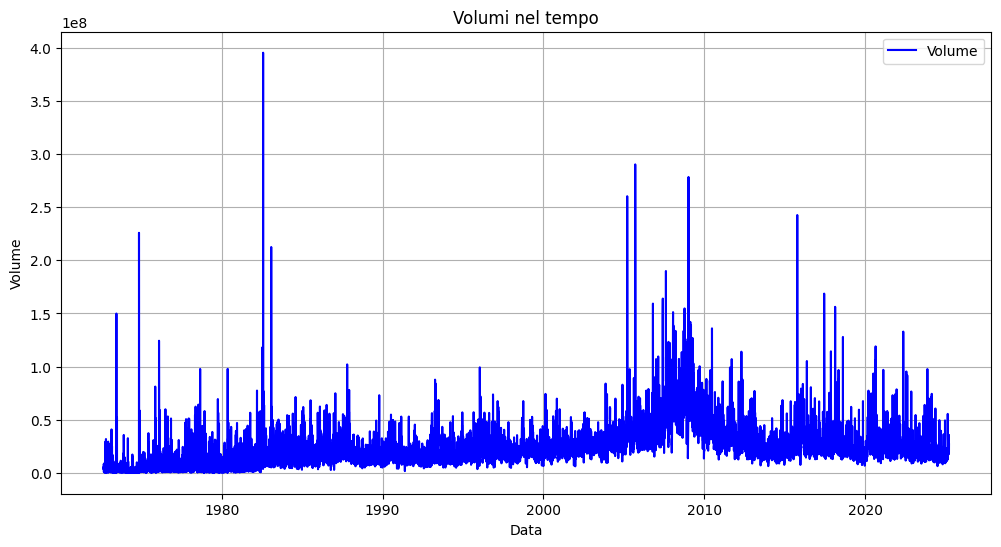

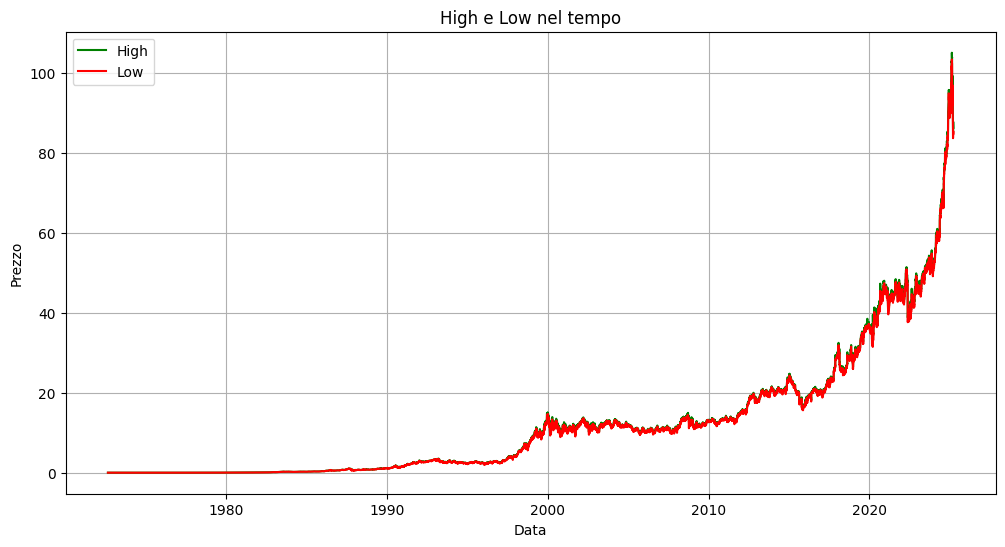

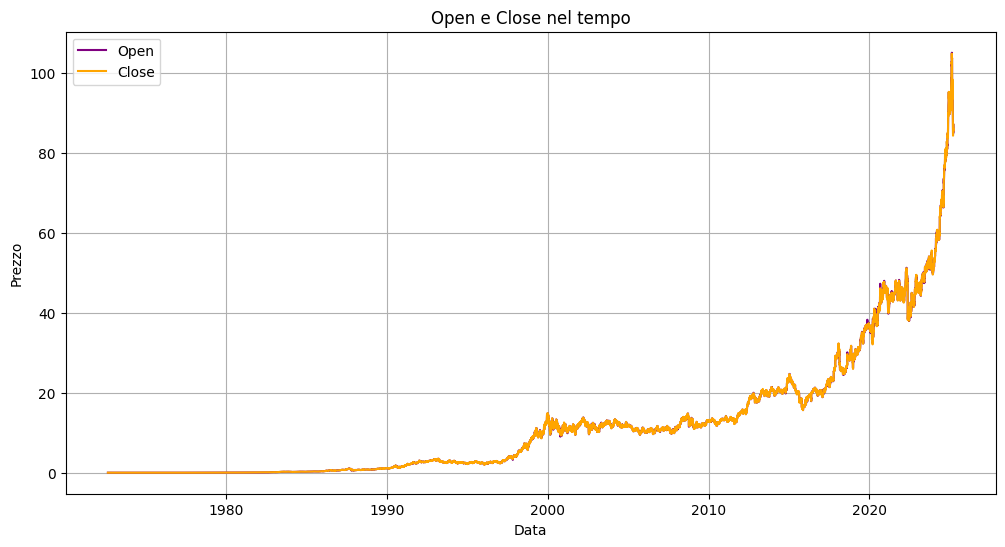

In [4]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_w['Date'], df_w['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_w['Date'], df_w['High'], label='High', color='green')
plt.plot(df_w['Date'], df_w['Low'], label='Low', color='red')
plt.title('High e Low nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_w['Date'], df_w['Open'], label='Open', color='purple')
plt.plot(df_w['Date'], df_w['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()


In [5]:
#trasformazione logaritmica
# Crea una copia di df_w
df_w_log = df_w.copy()

# Colonne numeriche da trasformare (escludi 'Date' e colonne non numeriche)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Applica la trasformazione logaritmica alle colonne numeriche
for col in numeric_cols:
    # Aggiungi una piccola costante per evitare logaritmi di zero o valori negativi
    df_w_log[col] = np.log(df_w_log[col])
# Visualizza le prime righe di df_w_log
print(df_w_log.head())

        Date      Open      High       Low     Close     Volume  Dividends  \
0 1972-08-25 -4.471408 -4.452356 -4.471408 -4.456165  15.833927        0.0   
1 1972-08-28 -4.456165 -4.448607 -4.459942 -4.459942  14.886546        0.0   
2 1972-08-29 -4.463733 -4.463733 -4.471407 -4.471407  15.579693        0.0   
3 1972-08-30 -4.471407 -4.471407 -4.479141 -4.471407  14.021549        0.0   
4 1972-08-31 -4.479141 -4.479141 -4.486935 -4.486935  14.775320        0.0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


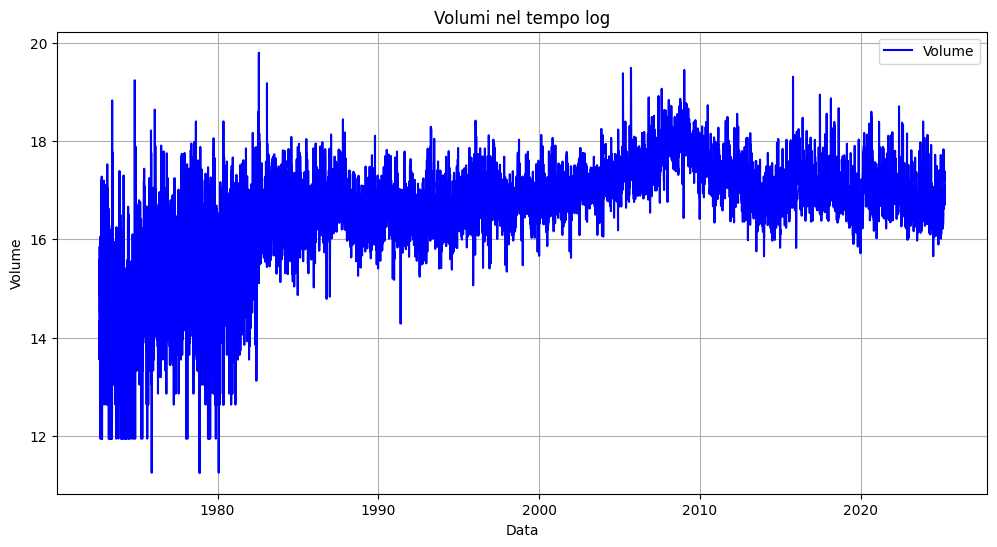

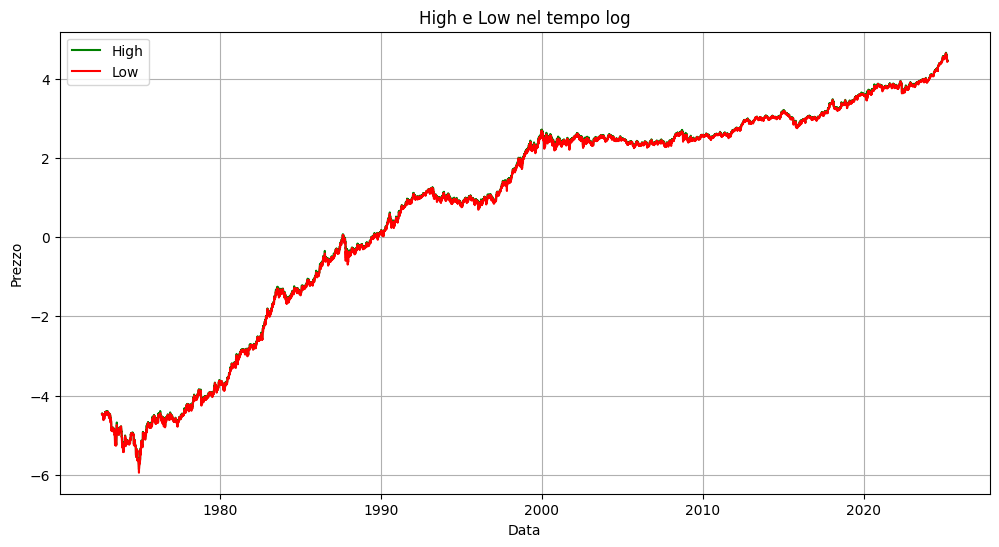

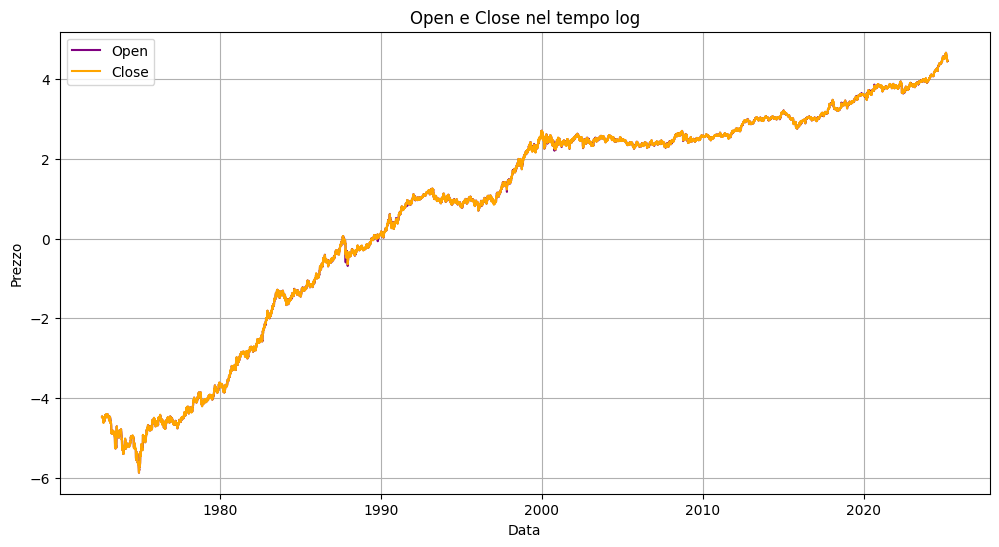

In [6]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_w_log['Date'], df_w_log['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo log')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_w_log['Date'], df_w_log['High'], label='High', color='green')
plt.plot(df_w_log['Date'], df_w_log['Low'], label='Low', color='red')
plt.title('High e Low nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_w_log['Date'], df_w_log['Open'], label='Open', color='purple')
plt.plot(df_w_log['Date'], df_w_log['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

       Open      High       Low     Close       Date
0       NaN       NaN       NaN       NaN 1972-08-25
1  0.015360  0.003756  0.011532 -0.003770 1972-08-28
2 -0.007540 -0.015013 -0.011399 -0.011399 1972-08-29
3 -0.007645 -0.007645 -0.007704  0.000000 1972-08-30
4 -0.007704 -0.007704 -0.007764 -0.015407 1972-08-31


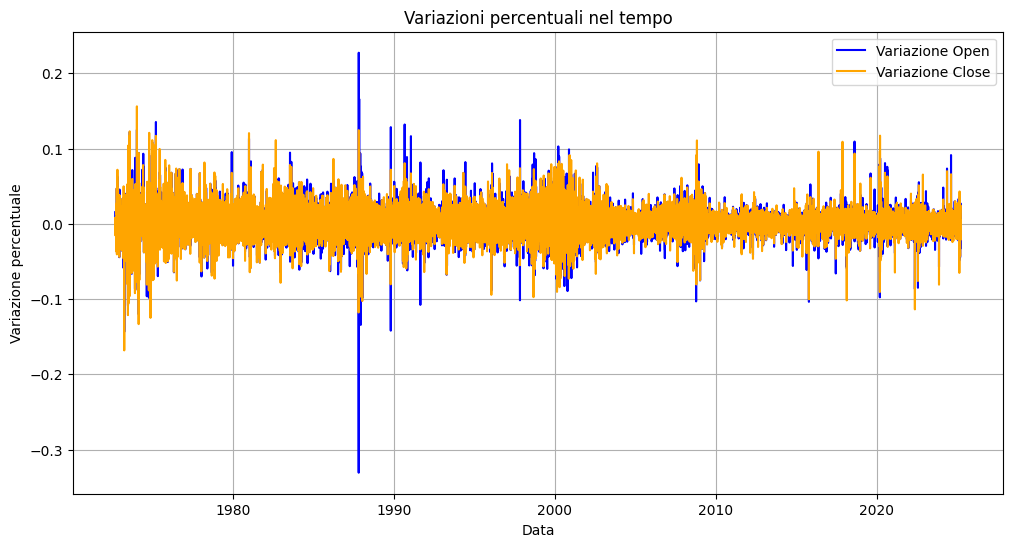

In [9]:
# Calcola le variazioni percentuali sui dati originali
variations_w = df_w[['Open', 'High', 'Low', 'Close']].pct_change()

# Aggiungi la colonna 'Date' al DataFrame delle variazioni
variations_w['Date'] = df_w['Date']

# Visualizza le prime righe del DataFrame delle variazioni
print(variations_w.head())

# Plot delle variazioni
plt.figure(figsize=(12, 6))
plt.plot(variations_w['Date'], variations_w['Open'], label='Variazione Open', color='blue')
plt.plot(variations_w['Date'], variations_w['Close'], label='Variazione Close', color='orange')
plt.title('Variazioni percentuali nel tempo')
plt.xlabel('Data')
plt.ylabel('Variazione percentuale')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
#dati originali
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test = adfuller(df_w[i])

    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: 5.580237463856838
P-value: 1.0
Valori critici: {'1%': np.float64(-3.43084707981339), '5%': np.float64(-2.8617596855154805), '10%': np.float64(-2.566886933689185)}
non stazionario
ADF test Close
Statistica ADF: 5.908768291554156
P-value: 1.0
Valori critici: {'1%': np.float64(-3.430847042031125), '5%': np.float64(-2.861759668818923), '10%': np.float64(-2.566886924801738)}
non stazionario
ADF test Volume
Statistica ADF: -4.9740377940367
P-value: 2.49742368899729e-05
Valori critici: {'1%': np.float64(-3.43084707981339), '5%': np.float64(-2.8617596855154805), '10%': np.float64(-2.566886933689185)}
stazionario


In [11]:
# dati log
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test_log = adfuller(df_w_log[i])

    # Estrai i risultati
    statistic = adf_test_log[0]
    pvalue = adf_test_log[1]
    critical_values = adf_test_log[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -1.6192989842918917
P-value: 0.47309683280186826
Valori critici: {'1%': np.float64(-3.430845798430433), '5%': np.float64(-2.861759119252742), '10%': np.float64(-2.566886632271989)}
non stazionario
ADF test Close
Statistica ADF: -1.5856052990565328
P-value: 0.4908203059846874
Valori critici: {'1%': np.float64(-3.4308460240765726), '5%': np.float64(-2.861759218969242), '10%': np.float64(-2.5668866853502936)}
non stazionario
ADF test Volume
Statistica ADF: -4.130647838367283
P-value: 0.0008615159089814005
Valori critici: {'1%': np.float64(-3.43084707981339), '5%': np.float64(-2.8617596855154805), '10%': np.float64(-2.566886933689185)}
stazionario


In [12]:
# Applica la differenziazione
df_w_trasf = df_w_log.diff().dropna()
#ADF sui dati trasformati
for i in lista:
    adf_test_trasf = adfuller(df_w_trasf[i])

    # Estrai i risultati
    statistic = adf_test_trasf[0]
    pvalue = adf_test_trasf[1]
    critical_values = adf_test_trasf[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -46.716320668272324
P-value: 0.0
Valori critici: {'1%': np.float64(-3.430845798430433), '5%': np.float64(-2.861759119252742), '10%': np.float64(-2.566886632271989)}
stazionario
ADF test Close
Statistica ADF: -31.980466157644678
P-value: 0.0
Valori critici: {'1%': np.float64(-3.4308460240765726), '5%': np.float64(-2.861759218969242), '10%': np.float64(-2.5668866853502936)}
stazionario
ADF test Volume
Statistica ADF: -28.02057230795441
P-value: 0.0
Valori critici: {'1%': np.float64(-3.4308471176014), '5%': np.float64(-2.861759702214577), '10%': np.float64(-2.5668869425779826)}
stazionario


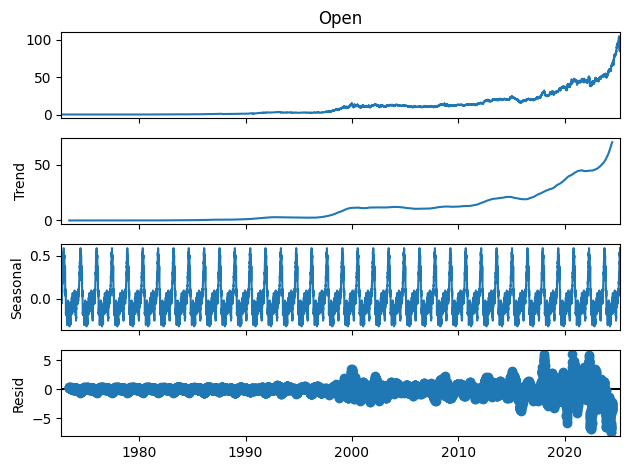

Statistica ADF sui residui: -10.68961578451032
P-value: 3.7552386052162803e-19
Valori critici: {'1%': np.float64(-3.430860825638947), '5%': np.float64(-2.8617657599907957), '10%': np.float64(-2.5668901670872044)}
stazionario


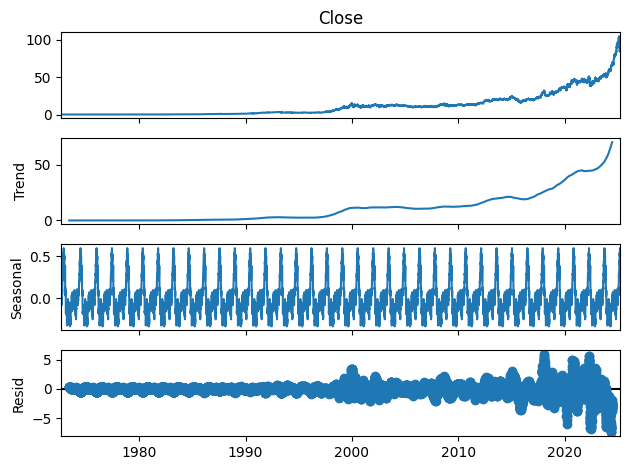

Statistica ADF sui residui: -10.441566905365821
P-value: 1.517257555203891e-18
Valori critici: {'1%': np.float64(-3.4308611051182876), '5%': np.float64(-2.8617658834963895), '10%': np.float64(-2.5668902328283636)}
stazionario


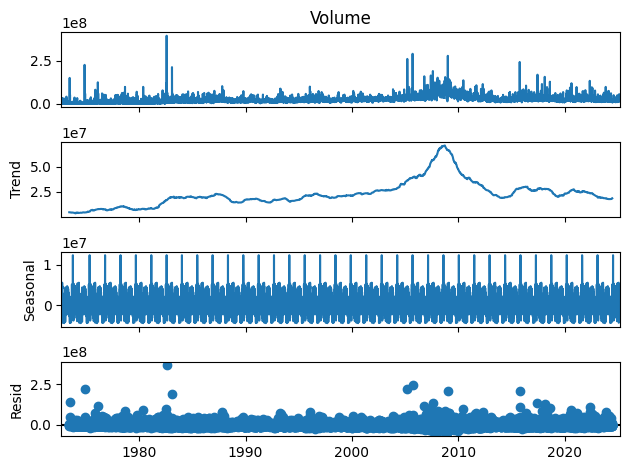

Statistica ADF sui residui: -20.293845109851077
P-value: 0.0
Valori critici: {'1%': np.float64(-3.4308603074159616), '5%': np.float64(-2.8617655309812164), '10%': np.float64(-2.566890045187021)}
stazionario


In [13]:
# Crea una copia di df_a
df_w_decomp = df_w.copy()

# Imposta la colonna 'Date' come indice
df_w_decomp.set_index('Date', inplace=True)

for i in lista:
    data = df_w_decomp[i]
    
    # Applica la decomposizione stagionale
    decomposition = seasonal_decompose(data, model='additive', period=365)  # Modifica il periodo se necessario
    
    # Visualizza la decomposizione
    decomposition.plot()
    plt.show()
    
    # Estrai i residui
    resid = decomposition.resid.dropna()
    
    # Esegui il test ADF sui residui
    adf_test = adfuller(resid)
    
    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]
    
    # Stampa i risultati
    print("Statistica ADF sui residui:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

In [14]:
#metodi di previsione con dataset stazionario
#preso i valori di close con operazione diff. e trasf. log. mentre i valori volume gli originali perhché già stazionari
data_w = pd.DataFrame({
    'Close': df_w_trasf['Close'],
    'Open': df_w_trasf['Open']
})
# Dividi i dati in train e test set
train_w, test_w = train_test_split(data_w, test_size=0.2, shuffle=False)

# Visualizza le dimensioni dei set
print("Dimensione train_w:", train_w.shape)
print("Dimensione test_w:", test_w.shape)

# Visualizza le prime righe dei set
print("\nTrain_w:")
print(train_w.head())
print(train_w.tail())

print("\nTest_w:")
print(test_w.head())
print(test_w.tail())

Dimensione train_w: (10559, 2)
Dimensione test_w: (2640, 2)

Train_w:
      Close      Open
1 -0.003777  0.015243
2 -0.011465 -0.007568
3  0.000000 -0.007674
4 -0.015527 -0.007734
5  0.007794 -0.003866
          Close      Open
10555  0.006705 -0.001849
10556 -0.001049  0.009473
10557 -0.000262 -0.000655
10558  0.008101  0.001832
10559 -0.006921  0.004438

Test_w:
          Close      Open
10560 -0.009348 -0.010341
10561  0.019387 -0.003559
10562 -0.012532  0.015722
10563  0.004849 -0.008879
10564 -0.005375 -0.002495
          Close      Open
13195  0.024421  0.001999
13196 -0.021613  0.026773
13197  0.008609 -0.017187
13198 -0.006042 -0.001630
13199  0.004722 -0.003453


In [15]:
#verifica di valori 0 o infinito
print(data_w['Close'][data_w['Close'].isna()])
print(data_w['Close'][np.isinf(data_w['Close'])])  
print(data_w['Open'][data_w['Open'].isna()])
print(data_w['Open'][np.isinf(data_w['Open'])])

# Gestisci il valore NaN (esempio: imputazione con la media)
data_w['Close'] = data_w['Close'].fillna(data_w['Close'].mean())
data_w['Open'] = data_w['Open'].fillna(data_w['Open'].mean())

# Verifica la correzione
print(data_w['Close'].isna().sum())
print(data_w['Close'].isin([np.inf, -np.inf]).sum())
print(data_w['Open'].isna().sum())
print(data_w['Open'].isin([np.inf, -np.inf]).sum())

Series([], Name: Close, dtype: float64)
Series([], Name: Close, dtype: float64)
Series([], Name: Open, dtype: float64)
Series([], Name: Open, dtype: float64)
0
0
0
0


In [17]:
lista1= ['Close', 'Open']
for i in lista1:
    adf_test_data_w = adfuller(data_w[i])
    
    # Estrai i risultati
    statistic = adf_test_data_w[0]
    pvalue = adf_test_data_w[1]
    critical_values = adf_test_data_w[4]
    
    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Close
Statistica ADF: -31.980466157644678
P-value: 0.0
Valori critici: {'1%': np.float64(-3.4308460240765726), '5%': np.float64(-2.861759218969242), '10%': np.float64(-2.5668866853502936)}
stazionario
ADF test Open
Statistica ADF: -46.716320668272324
P-value: 0.0
Valori critici: {'1%': np.float64(-3.430845798430433), '5%': np.float64(-2.861759119252742), '10%': np.float64(-2.566886632271989)}
stazionario


Close


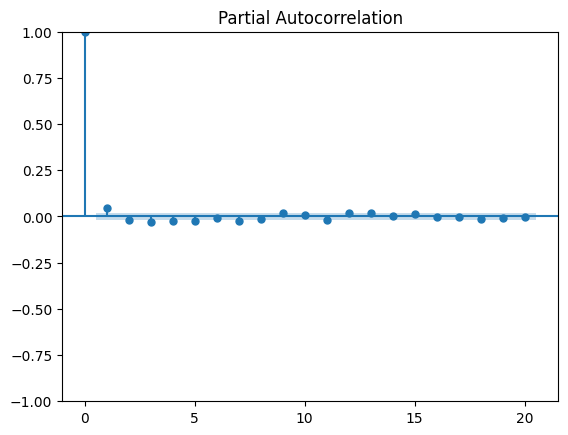

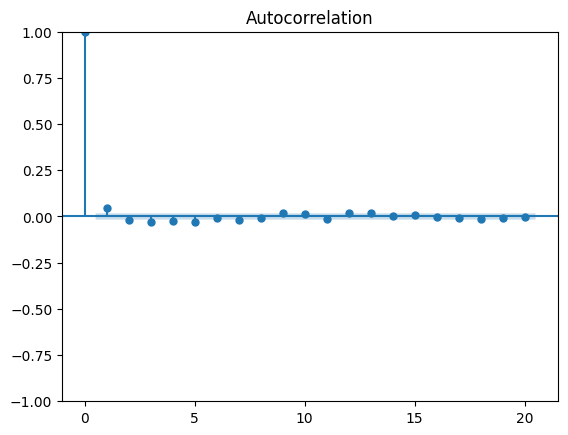

Open


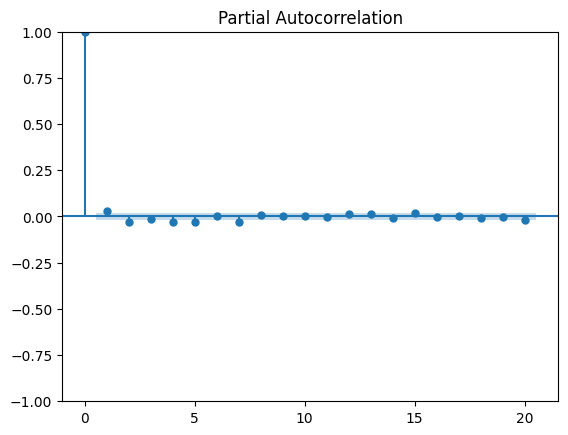

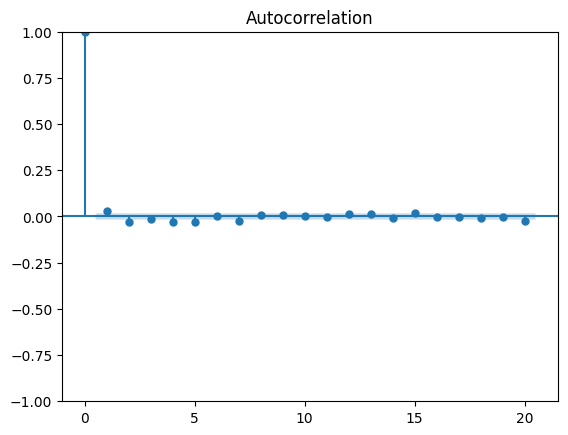

In [18]:
for campo in data_w:
    print (campo)
    plot_pacf(data_w[campo], lags=20)
    plt.show()
    plot_acf(data_w[campo], lags=20)
    plt.show()

In [19]:
def calcola_metriche(y_true, y_pred):
    # Rimuovi i valori NaN
    y_true = y_true.dropna()
    y_pred = y_pred.dropna()
    # Allinea gli indici per garantire che y_true e y_pred abbiano la stessa lunghezza
    y_true, y_pred = y_true.align(y_pred, join='inner')
    me = np.mean(y_pred - y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mpe = np.mean((y_true - y_pred) / y_true) * 100
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return me, rmse, mae, mpe, mape

In [20]:
def modello_arima(train,test,p,d,q):
    modello_arima = ARIMA(train, order=(p, d, q))
    risultati_arima = modello_arima.fit()
    # Effettua le previsioni sul set di train
    previsioni_train_arima = risultati_arima.predict(start=0, end=len(train) - 1)
    # Effettua le previsioni sul set di test
    previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
    me_train, rmse_train, mae_train, mpe_train, mape_train = calcola_metriche(train, previsioni_train_arima)
    print('Valutazione train')
    print(f"ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    me_test, rmse_test, mae_test, mpe_test, mape_test = calcola_metriche(test, previsioni_test_arima)
    print('Valutazione test')
    print(f"ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")
    # Visualizza le previsioni rispetto ai dati reali
    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()
    return risultati_arima

Close


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -1.1629810997576183e-06, RMSE: 0.01943019973365612, MAE: 0.013671153103322752, MPE: nan, MAPE: inf
Valutazione test
ME: 0.0001688439929488517, RMSE: 0.013369645352333863, MAE: 0.008742114605324586, MPE: -inf, MAPE: inf


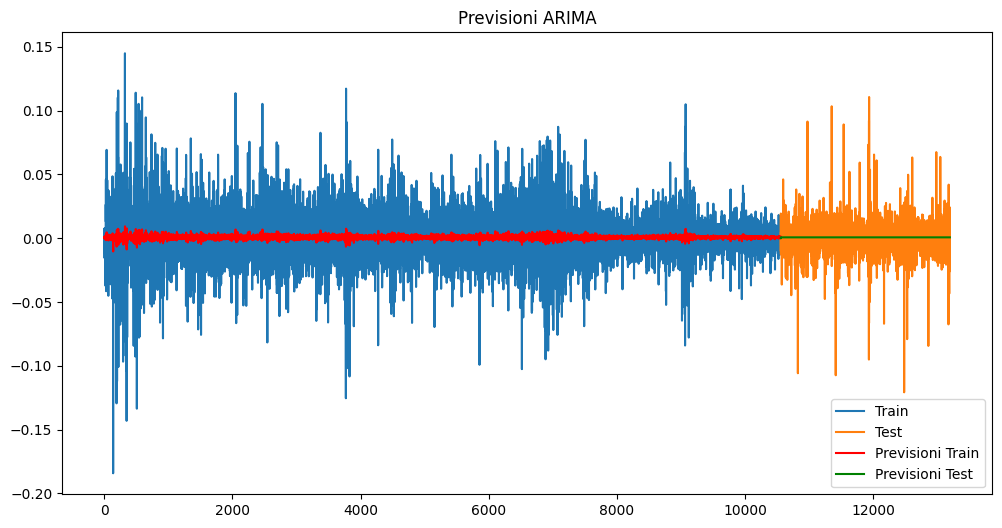

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -2.1492637375884816e-06, RMSE: 0.01972034013584459, MAE: 0.013290868759171803, MPE: nan, MAPE: inf
Valutazione test
ME: 0.00017229580914109345, RMSE: 0.01339763347325153, MAE: 0.008987612105205602, MPE: -17850.484066963163, MAPE: 22219.056010060274


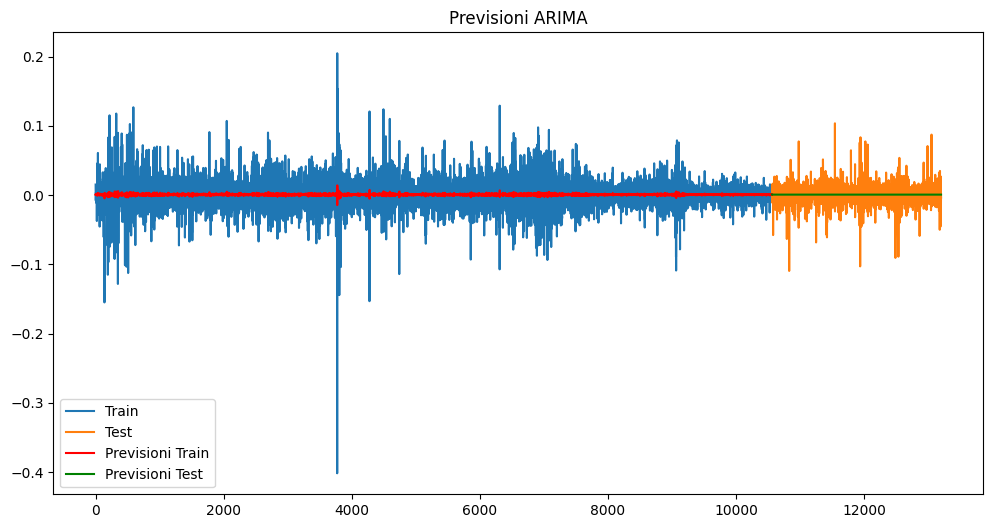

In [21]:
print ('Close')
modello_arima(train_w['Close'], test_w['Close'], 1, 0, 1)
print ('Open')
modello_arima(train_w['Open'], test_w['Open'], 1, 0, 1)

In [22]:
#arima iterativo
def modello_arima_iterativo(train, test, p_range, d_range, q_range):
    miglior_rmse = float('inf')
    miglior_modello = None
    migliori_parametri = None
    pdq = list(itertools.product(p_range, d_range, q_range))

    print(pdq)

    for param in pdq:
        rmse_test = None
        try:
            modello_arima = ARIMA(train, order=param)
            risultati_arima = modello_arima.fit()
            previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
            rmse_test = mean_squared_error(test, previsioni_test_arima, squared=False)

            if rmse_test < miglior_rmse:
                miglior_rmse = rmse_test
                miglior_modello = risultati_arima
                migliori_parametri = param

        except:
            pass

        print(f"Parametri: {param}, RMSE: {rmse_test}")

    print(f"Migliori parametri: {migliori_parametri}")
    print(f"Miglior RMSE: {miglior_rmse}")

    # Visualizza le previsioni del miglior modello (se trovato)
    if miglior_modello is not None:
        previsioni_train_arima = miglior_modello.predict(start=0, end=len(train) - 1)
        previsioni_test_arima = miglior_modello.predict(start=len(train), end=len(train) + len(test) - 1)
    else:
        previsioni_train_arima = np.zeros(len(train)) # Inizializza con zeri
        previsioni_test_arima = np.zeros(len(test)) # Inizializza con zeri

    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()

    return miglior_modello

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


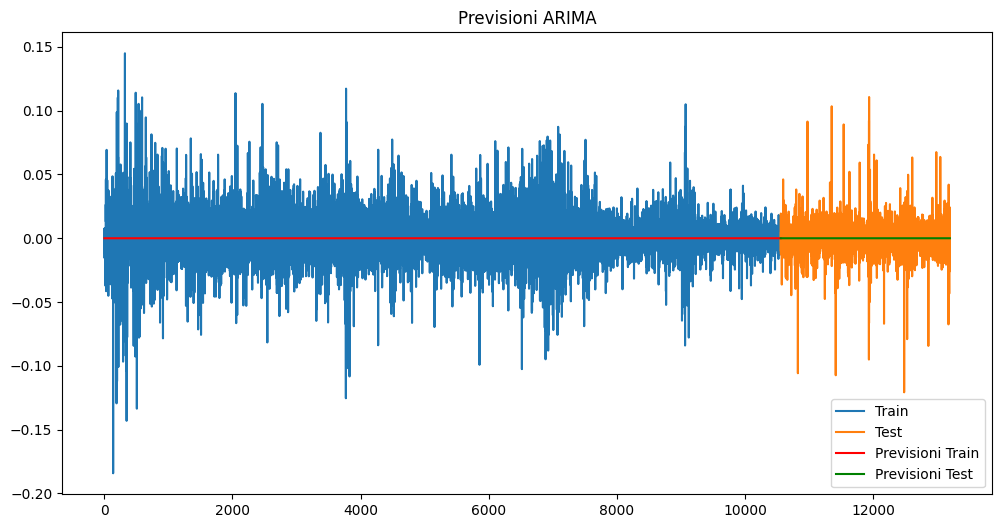

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


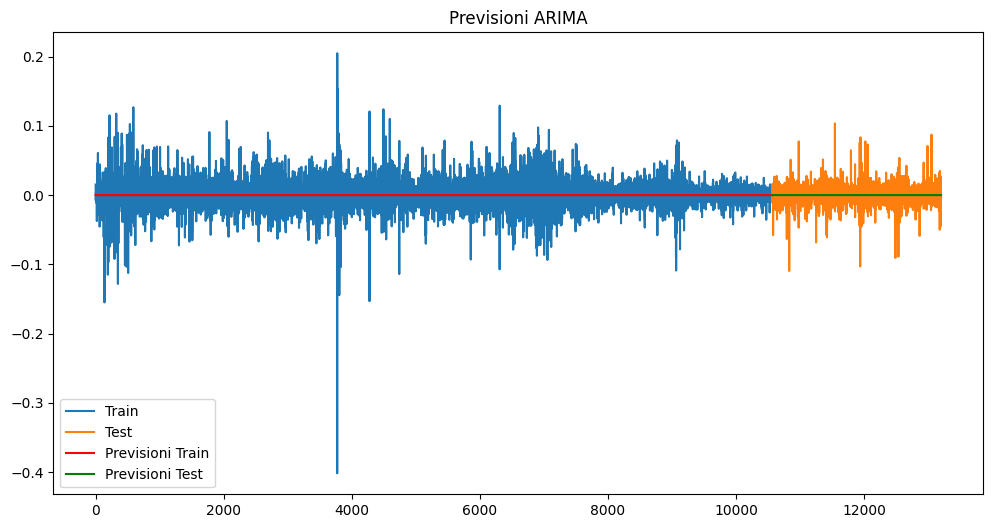

In [24]:
p_range = range(0, 4)
d_range = range(0, 3)
q_range = range(0, 4)
#arima a intervalli
miglior_modello = modello_arima_iterativo(train_w['Close'], test_w['Close'], p_range, d_range, q_range)
miglior_modello = modello_arima_iterativo(train_w['Open'], test_w['Open'], p_range, d_range, q_range)

In [26]:
#Prophet
data_w_prophet = pd.DataFrame({
    'ds': df_w['Date'],
    'Close': df_w_trasf['Close'],
    'Open': df_w_trasf['Open']
})
data_w_prophet['ds'] = pd.to_datetime(data_w_prophet['ds'])
# Gestisci il valore NaN (esempio: imputazione con la media)
data_w_prophet['Close'] = data_w_prophet['Close'].fillna(data_w['Close'].mean())
data_w_prophet['Open'] = data_w_prophet['Open'].fillna(data_w['Open'].mean())
# Dividi i dati in train e test set
train_w_prophet, test_w_prophet = train_test_split(data_w_prophet, test_size=0.2, shuffle=False)
train_w_prophet.head

<bound method NDFrame.head of               ds     Close      Open
0     1972-08-25  0.000675  0.000676
1     1972-08-28 -0.003777  0.015243
2     1972-08-29 -0.011465 -0.007568
3     1972-08-30  0.000000 -0.007674
4     1972-08-31 -0.015527 -0.007734
...          ...       ...       ...
10555 2014-09-16  0.006705 -0.001849
10556 2014-09-17 -0.001049  0.009473
10557 2014-09-18 -0.000262 -0.000655
10558 2014-09-19  0.008101  0.001832
10559 2014-09-22 -0.006921  0.004438

[10560 rows x 3 columns]>

In [27]:
#preparazione del train e test
# Preparazione dei dati per Prophet (Close)
train_w_close = train_w_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})
test_w_close = test_w_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})

# Preparazione dei dati per Prophet (Volume)
train_w_open = train_w_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})
test_w_open = test_w_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})

In [28]:
def modello_prophet(train,test):
    # Identifica e gestisci i valori nan nel train set
    train_nan_mask = train['y'].isna()
    train = train[~train_nan_mask]

    # Identifica e gestisci i valori nan nel test set
    test_nan_mask = test['y'].isna()
    test = test[~test_nan_mask]

    # Crea un modello Prophet
    model = Prophet(changepoint_prior_scale=0.01) # Valore più basso per ridurre l'overfitting

    # Addestra il modello sui dati di training
    model.fit(train)

    # Effettua le previsioni sul set di training
    forecast_train = model.predict(train)

    # Effettua le previsioni sul set di test
    forecast_test = model.predict(test)

    # Rimuovi i valori nan dalle previsioni e allinea gli indici
    forecast_test_nan_mask = forecast_test['yhat'].isna()
    forecast_test = forecast_test[~forecast_test_nan_mask].reset_index(drop=True) # Reset index
    test = test.reset_index(drop=True)[~forecast_test_nan_mask.reset_index(drop=True)] # reset and align index

    # Calcola le metriche di valutazione sul set di training
    me_train = np.mean(train['y'] - forecast_train['yhat'])
    rmse_train = np.sqrt(mean_squared_error(train['y'], forecast_train['yhat']))
    mae_train = np.mean(np.abs(train['y'] - forecast_train['yhat']))
    mpe_train = np.mean((train['y'] - forecast_train['yhat']) / train['y']) * 100
    mape_train = np.mean(np.abs((train['y'] - forecast_train['yhat']) / train['y'])) * 100

    # Calcola le metriche di valutazione sul set di test
    me_test = np.mean(test['y'] - forecast_test['yhat'])
    rmse_test = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
    mae_test = np.mean(np.abs(test['y'] - forecast_test['yhat']))
    mpe_test = np.mean((test['y'] - forecast_test['yhat']) / test['y']) * 100
    mape_test = np.mean(np.abs((test['y'] - forecast_test['yhat']) / test['y'])) * 100

    # Stampa le metriche di valutazione
    print('Valutazione train')
    print(f'ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}')

    print('Valutazione test')
    print(f'ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}')

    # Visualizza le previsioni rispetto ai valori reali
    plt.plot(train['ds'], train['y'], label='Train')
    plt.plot(test['ds'], test['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predictions')
    plt.legend()
    plt.show()

    # Visualizza i componenti del modello
    model.plot_components(forecast_test)
    plt.show()

    return model

Open


19:12:19 - cmdstanpy - INFO - Chain [1] start processing
19:12:20 - cmdstanpy - INFO - Chain [1] done processing


Valutazione train
ME: -3.1449215247093138e-06, RMSE: 0.019705595398788172, MAE: 0.013304379148001916, MPE: nan, MAPE: inf
Valutazione test
ME: 0.0006929423820463397, RMSE: 0.013427952273712185, MAE: 0.009044036692306122, MPE: -11053.795790316319, MAPE: 23419.225599388195


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


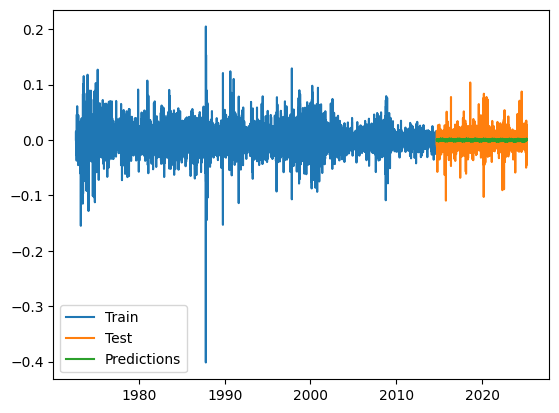

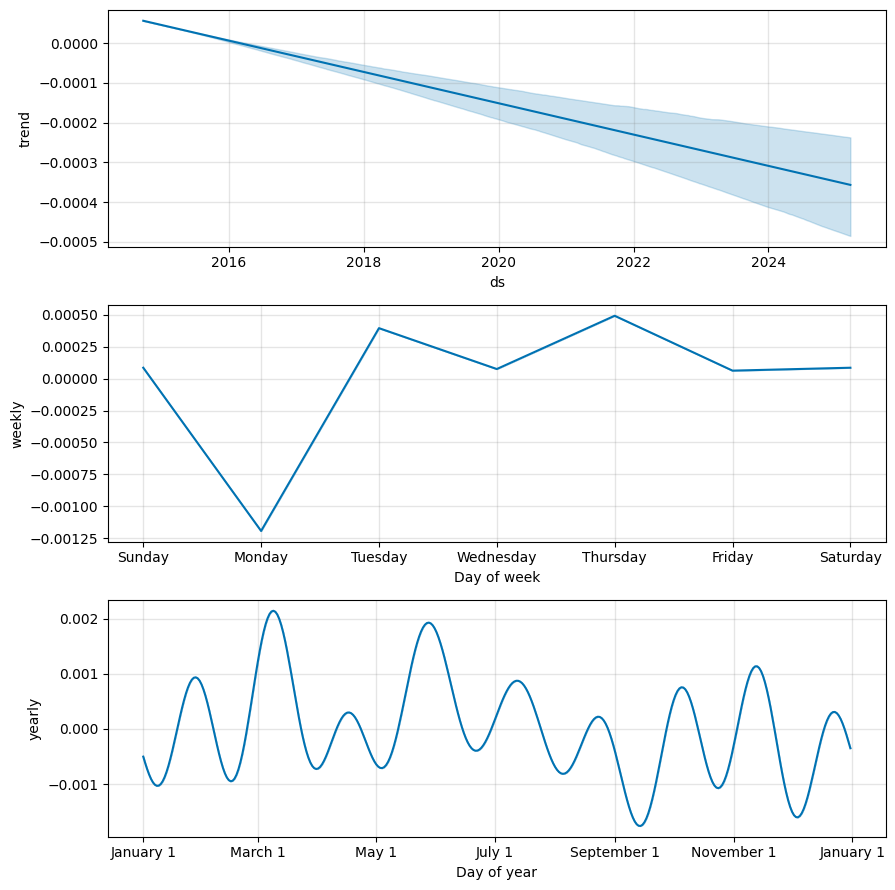

Close


19:12:24 - cmdstanpy - INFO - Chain [1] start processing
19:12:25 - cmdstanpy - INFO - Chain [1] done processing


Valutazione train
ME: -7.4843971457808975e-06, RMSE: 0.019442282585575576, MAE: 0.013652063517209396, MPE: nan, MAPE: inf
Valutazione test
ME: 0.00042724256224314103, RMSE: 0.013399994403094853, MAE: 0.008827101086105814, MPE: nan, MAPE: inf


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


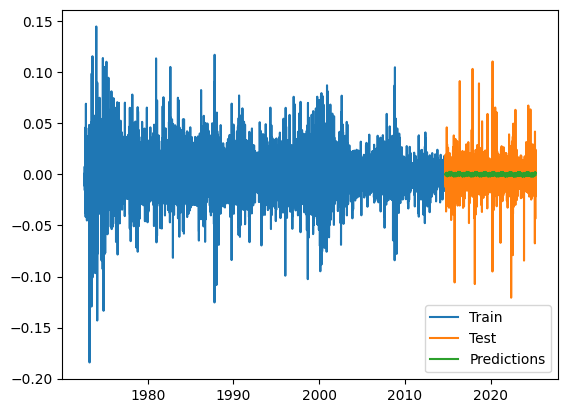

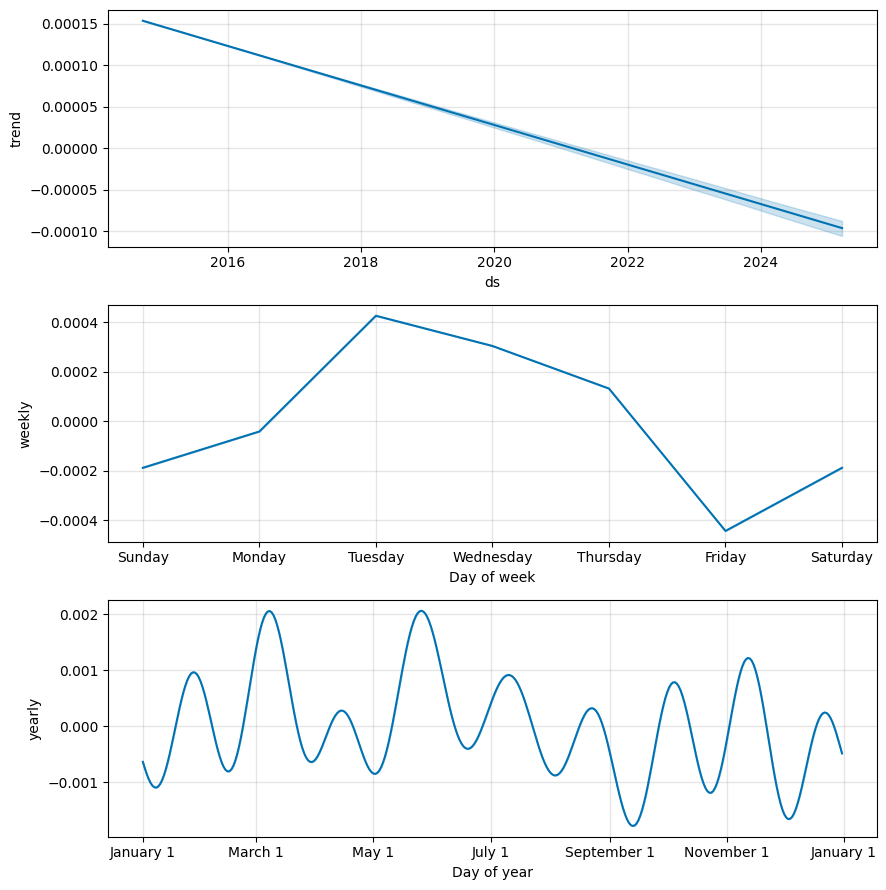

In [29]:
print ('Open')
# Applica il metodo a train_w_volume e test_w_volume
model_open = modello_prophet(train_w_open, test_w_open)

print ('Close')
# Applica il metodo a train_w_close e test_w_close
model_close = modello_prophet(train_w_close, test_w_close)

In [30]:
#RNN
# Preparazione del dataset usato dati log. per problemi di differenza di distribuzione dei dati tra train e test
close_data = df_w_log['Close'].values.reshape(-1, 1)
open_data = df_w_log['Open'].values.reshape(-1, 1)
#divisione train e test
train_w_rnn_close, test_w_rnn_close = train_test_split(close_data, test_size=0.2, shuffle=False)
train_w_rnn_open, test_w_rnn_open = train_test_split(open_data, test_size=0.2, shuffle=False)
print (train_w_rnn_close)

[[-4.45616524]
 [-4.45994249]
 [-4.4714074 ]
 ...
 [ 3.02663441]
 [ 3.03473532]
 [ 3.0278145 ]]


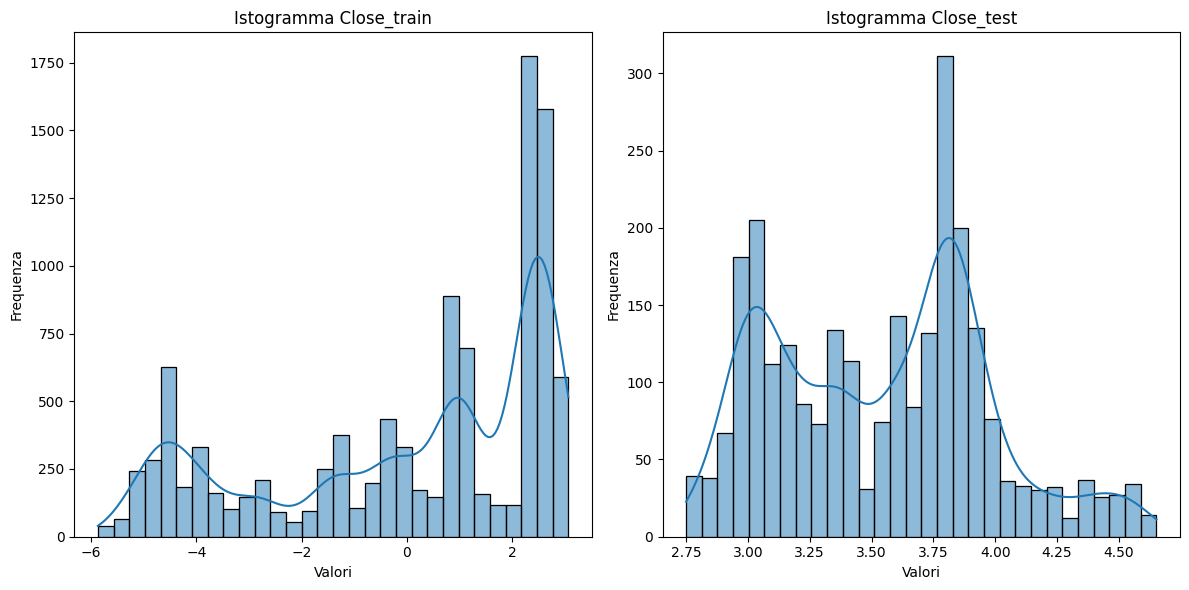

In [31]:
# Crea il istogrammi
# Appiattisci l'array in un array unidimensionale
train_w_rnn_close_flat = train_w_rnn_close.flatten()
df = pd.DataFrame({'valori': train_w_rnn_close_flat})

# Appiattisci l'array in un array unidimensionale
test_w_rnn_close_flat = test_w_rnn_close.flatten()
df_t = pd.DataFrame({'valori': test_w_rnn_close_flat,})


# Crea gli istogrammi
plt.figure(figsize=(12, 6))  # Imposta la dimensione della figura

plt.subplot(1, 2, 1)  # Crea il primo subplot (1 riga, 2 colonne, posizione 1)
sns.histplot(train_w_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_train')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.subplot(1, 2, 2)  # Crea il secondo subplot (1 riga, 2 colonne, posizione 2)
sns.histplot(test_w_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_test')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.tight_layout()  # Aggiusta la spaziatura tra i subplot
plt.show()

In [32]:
def modello_rnn(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.3, l2_rate=0.01):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1)) 
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello RNN
    model = Sequential()
    model.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Solo L2 a LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # Configura EarlyStopping
    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0) 
    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions') 
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: 0.2896792331043251, RMSE: 0.3146638096985563, MAE: 0.2902899073894087, MPE: 13.533763636299442, MAPE: 51.80688228689431
Valutazione test
ME: 0.7804834582206207, RMSE: 0.7987226276243462, MAE: 0.7804834582206207, MPE: 21.759498040672337, MAPE: 21.759498040672337


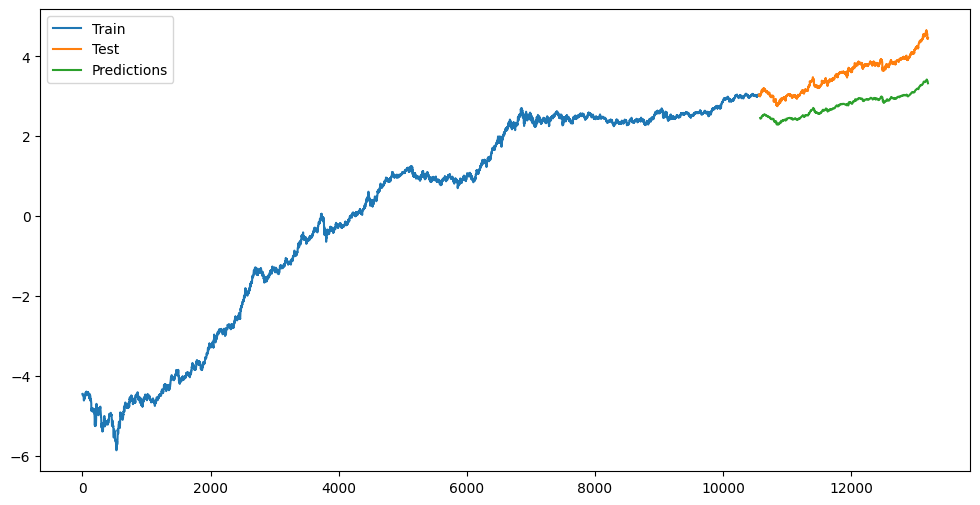

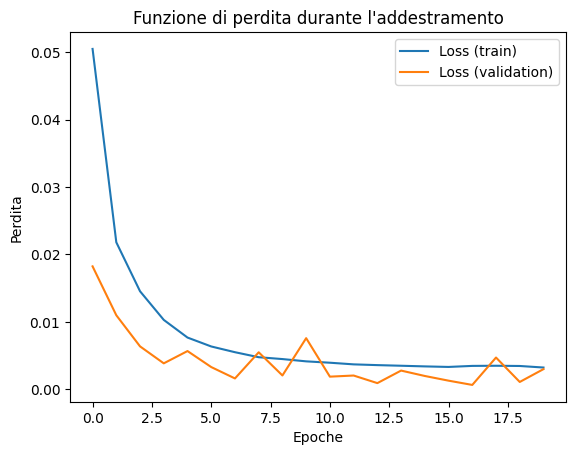

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: 0.23177395863890743, RMSE: 0.41437823970314475, MAE: 0.3765666737733963, MPE: 8.399434709478253, MAPE: 68.11491400964583
Valutazione test
ME: 0.8650340738704234, RMSE: 0.8804734517649897, MAE: 0.8650340738704234, MPE: 24.210524376174096, MAPE: 24.210524376174096


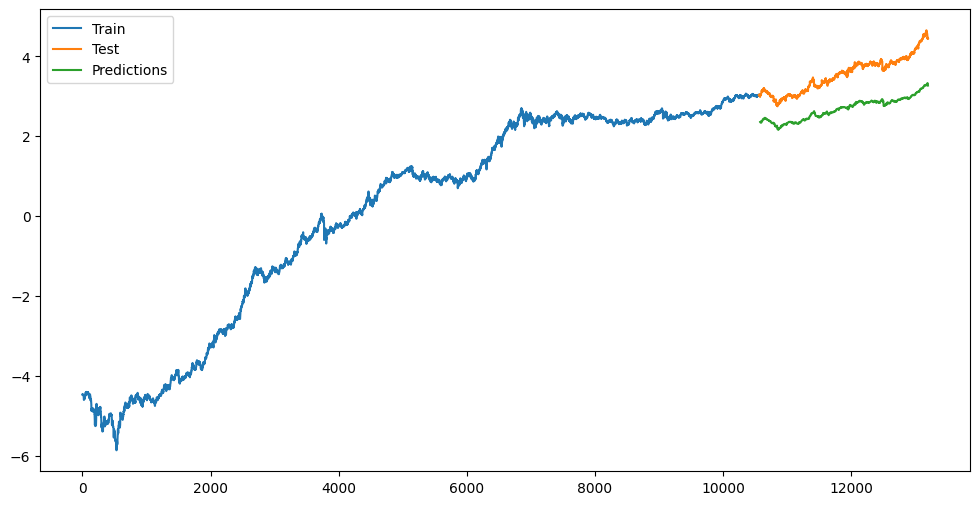

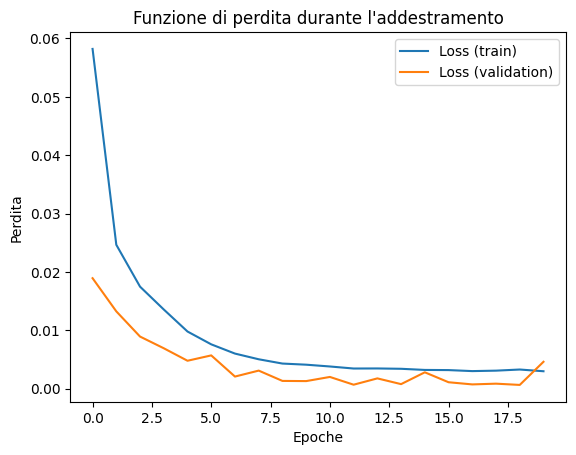

In [33]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_w_close, history_close = modello_rnn(train_w_rnn_close, test_w_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_w_open, history_open = modello_rnn(train_w_rnn_open, test_w_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

In [35]:
#LSTM
def modello_lstm(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.2, l2_rate=0.001):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1))
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello LSTM con Dropout e L2
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Utilizza LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stopping])

    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions')
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: -0.09374511878070384, RMSE: 0.17892411287457413, MAE: 0.12688926827835817, MPE: -1.8831261190660582, MAPE: 25.628193230480367
Valutazione test
ME: 0.021944771537460998, RMSE: 0.05827843888772654, MAE: 0.04619233568627553, MPE: 0.7327046416966985, MAPE: 1.3341387298972185


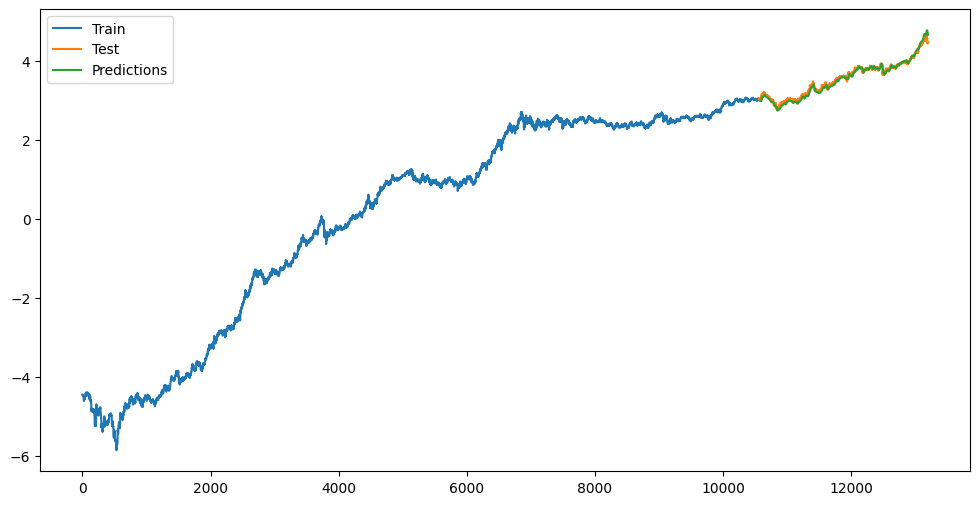

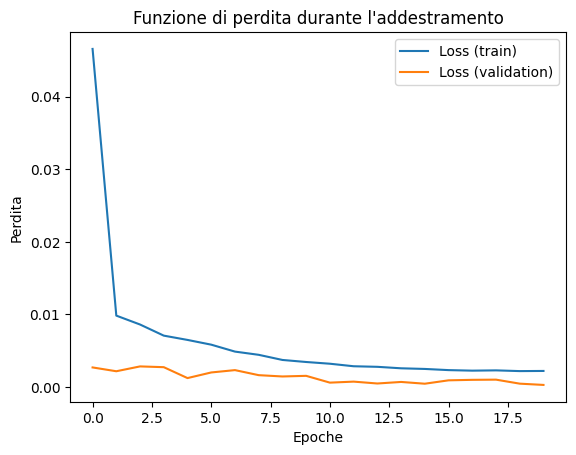

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Valutazione train
ME: 0.06117478617740871, RMSE: 0.08908141840260597, MAE: 0.07088051499356231, MPE: -1.601953722277318, MAPE: 15.811229350750578
Valutazione test
ME: -0.01730245583220727, RMSE: 0.09486143579728357, MAE: 0.06784925344112817, MPE: -0.24733939484713785, MAPE: 1.8461456839233201


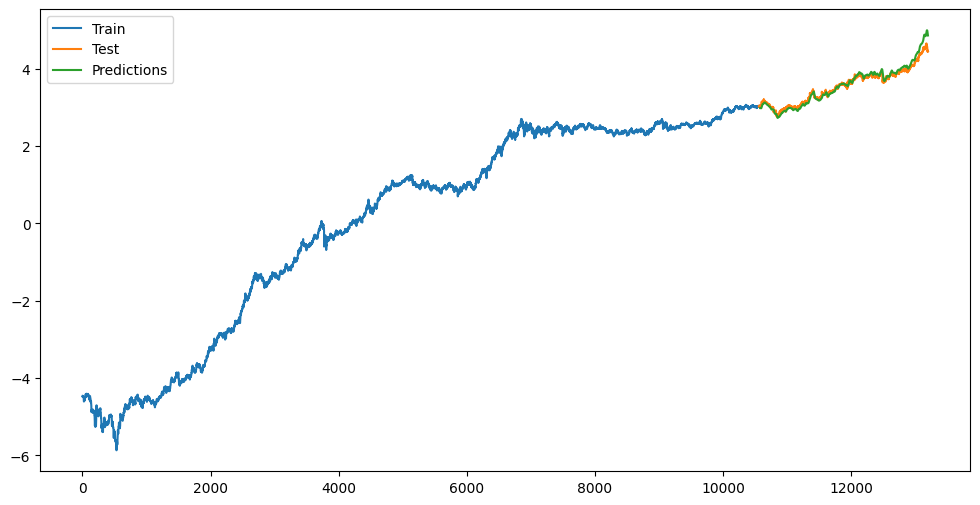

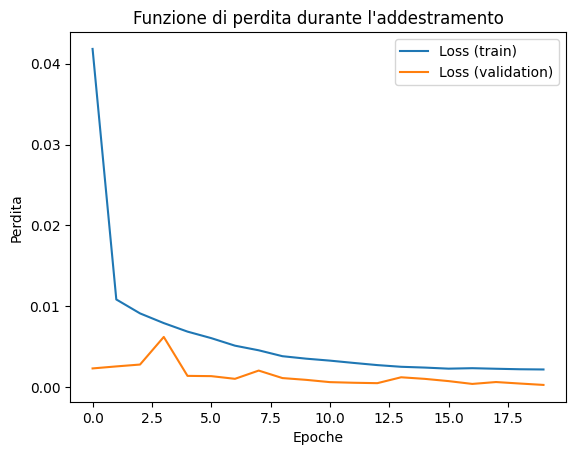

In [36]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_w_close, history_close = modello_lstm(train_w_rnn_close, test_w_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_w_open, history_open = modello_lstm(train_w_rnn_open, test_w_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()